In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
df = pd.read_csv("db/benchmark_results/eval/metrics_history.csv", sep=";")
df.head()

,id_turno,id_sessao,modelo,juiz,modo_rag,arquivo_origem,turno,style_rev,event_caus,adherence,time_order
0,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,1,1.000,0.917,1.0,1.0
1,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,2,0.875,0.875,1.0,1.0
2,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,3,1.000,0.917,1.0,1.0
3,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,4,1.000,0.917,1.0,1.0
4,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,adv_desert_01_gemini-2.5-flash_baseline_rep1_1...,gemini-2.5-flash_baseline_rep1,groq,Baseline (Sem RAG),transcript_adv_desert_01_gemini-2.5-flash_base...,5,0.875,0.833,1.0,1.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_turno        45 non-null     str    
 1   id_sessao       45 non-null     str    
 2   modelo          45 non-null     str    
 3   juiz            45 non-null     str    
 4   modo_rag        45 non-null     str    
 5   arquivo_origem  45 non-null     str    
 6   turno           45 non-null     int64  
 7   style_rev       45 non-null     float64
 8   event_caus      45 non-null     float64
 9   adherence       45 non-null     float64
 10  time_order      45 non-null     float64
dtypes: float64(4), int64(1), str(6)
memory usage: 14.4 KB


In [8]:
metricas = ['style_rev', 'event_caus', 'adherence', 'time_order']

## Agrupamento por arquitetura (RAG ou nao)

In [9]:
resumo_modo = df.groupby('modo_rag')[metricas].mean().reset_index()
print("Médias Gerais por Abordagem:")
print(resumo_modo)

Médias Gerais por Abordagem:
             modo_rag  style_rev  event_caus  adherence  time_order
0  Baseline (Sem RAG)      0.880     0.87676       0.72      0.9600
1          RAG Ligado      0.875     0.86790       0.80      0.9125


C:\Users\Aragão\AppData\Local\Temp\ipykernel_9148\3193755519.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')


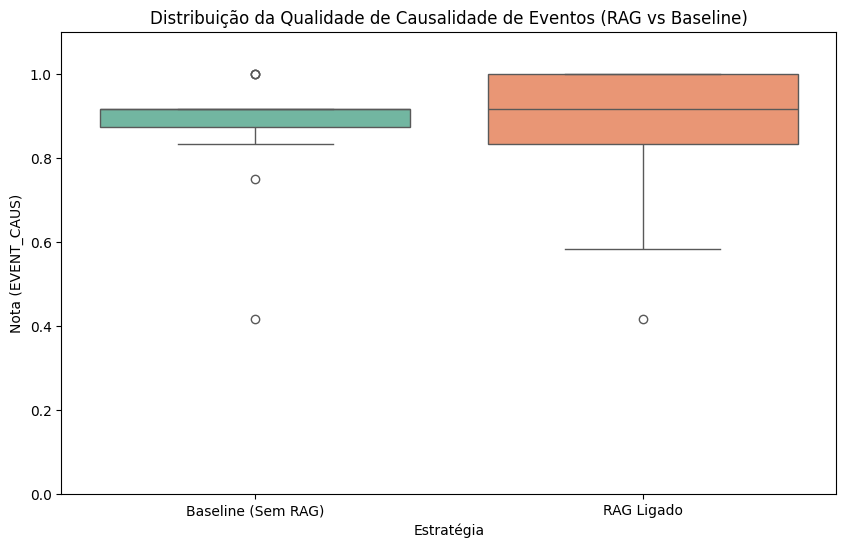

In [10]:
plt.figure(figsize=(10, 6))
# Exemplo focado na Causalidade de Eventos
sns.boxplot(data=df, x='modo_rag', y='event_caus', palette='Set2')

plt.title('Distribuição da Qualidade de Causalidade de Eventos (RAG vs Baseline)')
plt.ylabel('Nota (EVENT_CAUS)')
plt.xlabel('Estratégia')
plt.ylim(0, 1.1) # Padroniza o eixo Y de 0 a 1 (com um respiro)
plt.show()

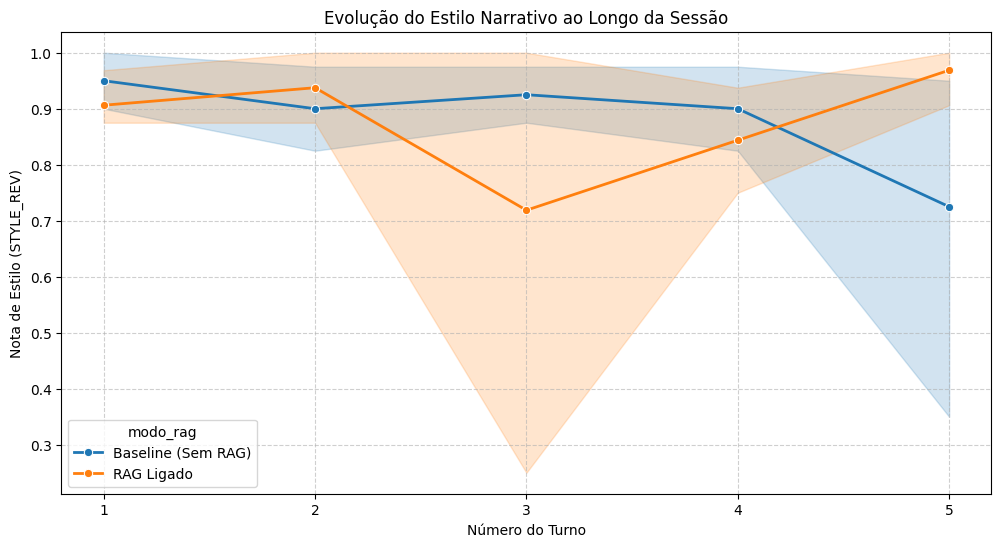

In [11]:
plt.figure(figsize=(12, 6))
# O Seaborn automaticamente calcula a média por turno e desenha uma margem de erro (intervalo de confiança)
sns.lineplot(data=df, x='turno', y='style_rev', hue='modo_rag', marker='o', linewidth=2)

plt.title('Evolução do Estilo Narrativo ao Longo da Sessão')
plt.ylabel('Nota de Estilo (STYLE_REV)')
plt.xlabel('Número do Turno')
plt.xticks(range(1, df['turno'].max() + 1)) # Garante que os números no eixo X sejam inteiros
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Agrupamento por modelo que Mestrou

In [13]:
df_agg_modelo = df.groupby('modelo')[metricas].mean().reset_index()

print("Média de Desempenho por Modelo:")
print(df_agg_modelo)

Média de Desempenho por Modelo:
                                     modelo  style_rev  event_caus  adherence  \
0            gemini-2.5-flash_baseline_rep1     0.9750      0.9210      0.975   
1                 gemini-2.5-flash_rag_rep1     0.9375      0.9190      0.975   
2          openai_gpt-4o-mini_baseline_rep1     0.9000      0.8959      0.725   
3               openai_gpt-4o-mini_rag_rep1     0.9000      0.8668      0.750   
4  qwen_qwen-2.5-72b-instruct_baseline_rep1     0.6500      0.7500      0.200   
5       qwen_qwen-2.5-72b-instruct_rag_rep1     0.7250      0.7668      0.500   

   time_order  
0        1.00  
1        1.00  
2        1.00  
3        1.00  
4        0.80  
5        0.65  


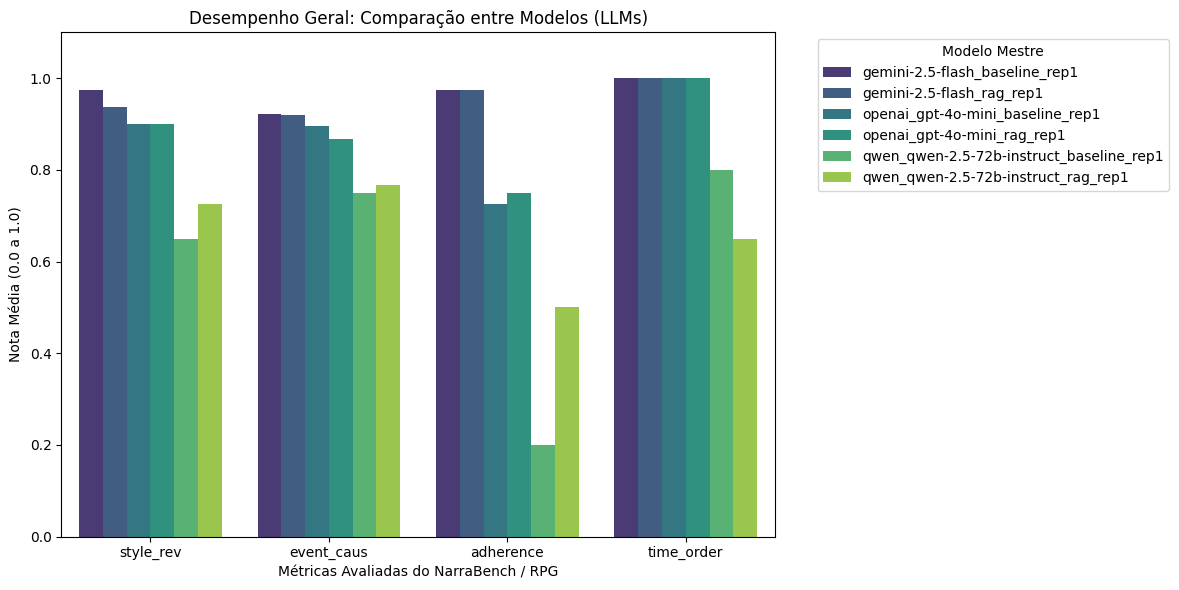

In [14]:
df_melted = df.melt(id_vars=['modelo'], value_vars=metricas, var_name='Metrica', value_name='Nota')

plt.figure(figsize=(12, 6))
# ci=None remove as linhas de erro para deixar o gráfico mais limpo, mas pode usar ci='sd' se quiser mostrar o desvio padrão
sns.barplot(data=df_melted, x='Metrica', y='Nota', hue='modelo', errorbar=None, palette='viridis')

plt.title('Desempenho Geral: Comparação entre Modelos (LLMs)')
plt.ylabel('Nota Média (0.0 a 1.0)')
plt.xlabel('Métricas Avaliadas do NarraBench / RPG')
plt.ylim(0, 1.1) # Vai de 0 a 1, com uma margem de segurança
plt.legend(title='Modelo Mestre', bbox_to_anchor=(1.05, 1), loc='upper left') # Coloca a legenda do lado de fora

plt.tight_layout()
plt.show()